# Environment setup

This notebook is the entry point for Colab-based experiments.

In [ ]:
import os
import sys
from pathlib import Path

repo_root = Path('/content/realistic-heterogeneity-intermittent-connectivity')
if repo_root.exists():
    sys.path.insert(0, str(repo_root))

from src import get_project_summary

get_project_summary()

# Realistic Heterogeneity and Intermittent Connectivity in Federated Learning

## Notebook 01: Environment Setup & Dataset Verification

### Objectives

- Verify Google Colab environment
- Verify GPU availability
- Clone the project repository
- Download CIFAR-10
- Explore the dataset
- Prepare for federated learning experiments

This notebook serves as the foundation for all subsequent experiments.

In [5]:
import platform
import sys

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("Processor:", platform.processor())

SYSTEM INFORMATION
Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Processor: x86_64


In [6]:
import torch

print("=" * 60)
print("GPU INFORMATION")
print("=" * 60)

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
    print("GPU Count       :", torch.cuda.device_count())
else:
    print("Running on CPU")

GPU INFORMATION
PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU Name        : Tesla T4
GPU Count       : 1


In [7]:
!nvidia-smi

Mon Jul 13 02:08:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
import os

repo = "realistic-heterogeneity-intermittent-connectivity"

if not os.path.exists(repo):
    !git clone https://github.com/deepayansinha/realistic-heterogeneity-intermittent-connectivity

%cd realistic-heterogeneity-intermittent-connectivity

Cloning into 'realistic-heterogeneity-intermittent-connectivity'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 56 (delta 15), reused 37 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 15.28 KiB | 7.64 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/realistic-heterogeneity-intermittent-connectivity


In [9]:
import os

folders = [
    "src",
    "notebooks",
    "configs",
    "tests",
]

print("=" * 60)
print("PROJECT STRUCTURE")
print("=" * 60)

for folder in folders:
    print(f"{folder:<15}", "✓" if os.path.exists(folder) else "✗")

PROJECT STRUCTURE
src             ✓
notebooks       ✓
configs         ✓
tests           ✓


In [4]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)
print("Training Images :", len(trainset))
print("Testing Images  :", len(testset))

100%|██████████| 170M/170M [53:06<00:00, 53.5kB/s]


DATASET LOADED
Training Images : 50000
Testing Images  : 10000


In [5]:

classes = trainset.classes

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Classes:")
for i, cls in enumerate(classes):
    print(f"{i}: {cls}")

print("\nNumber of Classes:", len(classes))
print("Training Samples :", len(trainset))
print("Testing Samples  :", len(testset))

DATASET INFORMATION
Classes:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck

Number of Classes: 10
Training Samples : 50000
Testing Samples  : 10000


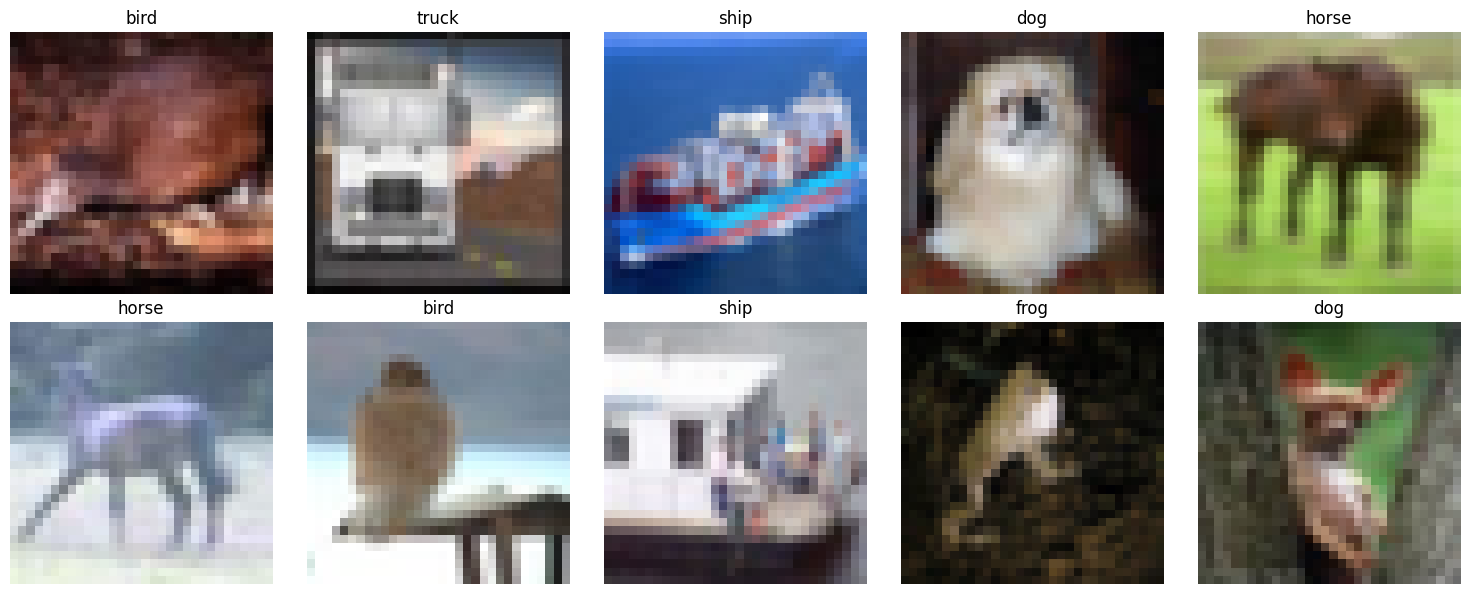

In [6]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(15,6))

for i in range(10):
    idx = random.randint(0, len(trainset)-1)

    image, label = trainset[idx]

    plt.subplot(2,5,i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from collections import Counter

labels = [label for _, label in trainset]

counts = Counter(labels)

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for i in range(len(classes)):
    print(f"{classes[i]:<12} : {counts[i]}")

CLASS DISTRIBUTION
airplane     : 5000
automobile   : 5000
bird         : 5000
cat          : 5000
deer         : 5000
dog          : 5000
frog         : 5000
horse        : 5000
ship         : 5000
truck        : 5000


In [8]:
image, label = trainset[0]

print("=" * 60)
print("SAMPLE IMAGE")
print("=" * 60)

print("Image Shape :", image.shape)
print("Data Type   :", image.dtype)
print("Label       :", label)
print("Class Name  :", classes[label])

SAMPLE IMAGE
Image Shape : torch.Size([3, 32, 32])
Data Type   : torch.float32
Label       : 6
Class Name  : frog


In [9]:
print("=" * 60)
print("NOTEBOOK 01 SUMMARY")
print("=" * 60)

print("✓ Colab Environment Verified")
print("✓ GPU Verified")
print("✓ Repository Connected")
print("✓ CIFAR-10 Downloaded")
print("✓ Dataset Explored")
print("✓ Ready for Data Partitioning")

NOTEBOOK 01 SUMMARY
✓ Colab Environment Verified
✓ GPU Verified
✓ Repository Connected
✓ CIFAR-10 Downloaded
✓ Dataset Explored
✓ Ready for Data Partitioning
